# Regression. Part 1
---
В данном ноутбуке будут рассмотрены регрессионные модели, метрики численного прогнозирования и методы подготовки признаков.

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Линейная регрессия

In [55]:
df = pd.read_csv('linear_regression.csv')

In [56]:
df.head()

,x,y
0,24,21.549452
1,50,47.464463
2,15,17.218656
3,38,36.586398
4,87,87.288984


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       700 non-null    int64  
 1   y       700 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 11.1 KB


In [58]:
X_train, X_test, y_train, y_test = train_test_split(df[['x']], df['y'], test_size=0.2, random_state=42)

<Axes: title={'center': 'Data visualisation'}, xlabel='x', ylabel='y'>

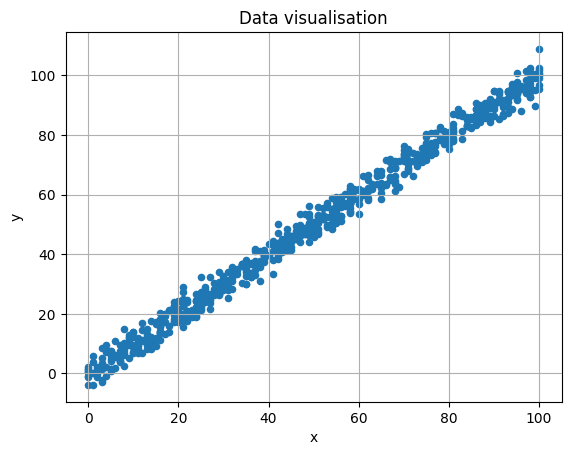

In [59]:
df.plot.scatter(x='x', y='y', xlabel='x', ylabel='y', title='Data visualisation', grid=True)

In [60]:
from sklearn.linear_model import LinearRegression

In [61]:
reg = LinearRegression().fit(X_train, y_train)

In [62]:
reg.coef_

array([1.00089617])

In [63]:
reg.intercept_

np.float64(-0.14006817009452277)

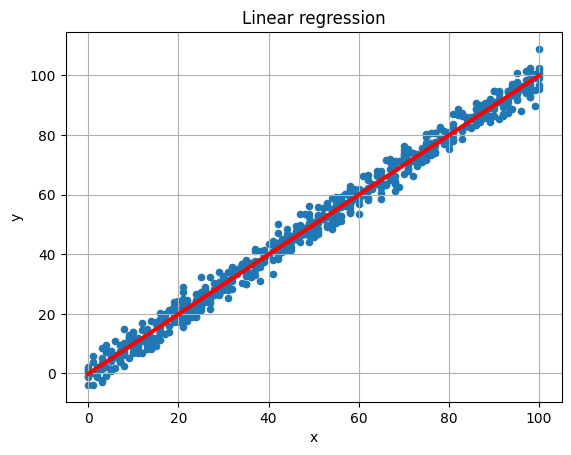

In [64]:
df.plot.scatter(x='x', y='y', xlabel='x', ylabel='y', title='Linear regression', grid=True)
plt.plot([0, 100], [0*reg.coef_[0]+reg.intercept_, 100*reg.coef_[0]+reg.intercept_], color='red', linewidth=3)

Линейная регрессия прекрасно ложится на наши данные. Посмотрим, какую оценку модели мы получаем.

In [65]:
print('Train:', reg.score(X_train, y_train))
print('Test:', reg.score(X_test, y_test))

Train: 0.990380796581592
Test: 0.9915260812752268


Однако, что это за метрика? Чаще всего в процессе обучения модели используют квадрат ошибки в функциях потерь. Возможно, эта метрика нам и показана.

MSE - mean squared error.

$$MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i-f(x_i))^2$$

Из-за возведения в квадрат не очень понятно, как интерпретировать эту метрику, поэтому зачастую берут корень из этой метрики: RMSE - root mean squared error.

In [66]:
from sklearn.metrics import mean_squared_error as MSE

In [67]:
print('MSE:', MSE(reg.predict(X_test), y_test))
print('RMSE:', MSE(reg.predict(X_test), y_test)**0.5)

MSE: 8.004011606213526
RMSE: 2.829136194355713


Метрики не похожи по значению на полученные ранее.

Поскольку MSE и RMSE никак не ограничены сверху, иногда их очень сложно интерпретировать и понимать, хорошее ли это значение. Поэтому придумана метрика, изменяющаяся от 0 до 1 - $R^2$ или коэффициент детерминации. Этот показатель отражает, какая доля вариативности зависимой переменной объясняется независимыми переменными в модели.

$$R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i-f(x_i))^2}{\sum_{i=1}^{N} (y_i-\bar y)^2}$$

In [68]:
from sklearn.metrics import r2_score

In [69]:
print('R2:', r2_score(reg.predict(X_test), y_test))

R2: 0.9914583109695955


Теперь мы получили ту самую метрику. Чаще всего именно $R^2$ является очновной метрикой для регрессионных моделей. Чем ближе к единице, тем лучше.

Хотя R-квадрат изменяется от 0 до 1, на практие можно столкнуться с тем, что эта метрика окажется отрицательной. Это свидельствует о том, что построенная модель предсказывает хуже, чем константная модель.

Какие ещё метрики можно использовать при оценке модели?

Самое простое посмотреть, на сколько мы ошибаемся в абсолютных значениях.

MAE - mean absolute error. А когда мы говорим об относительных значениях, используем MAPE - mean absolute percentage error.

In [70]:
from sklearn.metrics import mean_absolute_error as MAE, mean_absolute_percentage_error as MAPE

In [71]:
print('MAE:', MAE(reg.predict(X_test), y_test))
print('MAPE:', MAPE(reg.predict(X_test), y_test))

MAE: 2.263741325510488
MAPE: 0.2802113257816474


Какие ещё метрики вы бы могли использовать?

Например, доля предсказаний с абсолютными ошибками больше некоторого значения. Попробуйте посчитать такое значение.

In [72]:
predictions = reg.predict(X_test)
absolute_errors = abs(predictions - y_test)

abs_error_threshold = 5

proportion_large_errors = (absolute_errors > abs_error_threshold).mean()

print(f"Доля предсказаний с абсолютными ошибками > {abs_error_threshold}: {proportion_large_errors:.4f}")

Доля предсказаний с абсолютными ошибками > 5: 0.0786


# Кодирование признаков

In [73]:
df = pd.read_csv('insurance.csv')

In [74]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


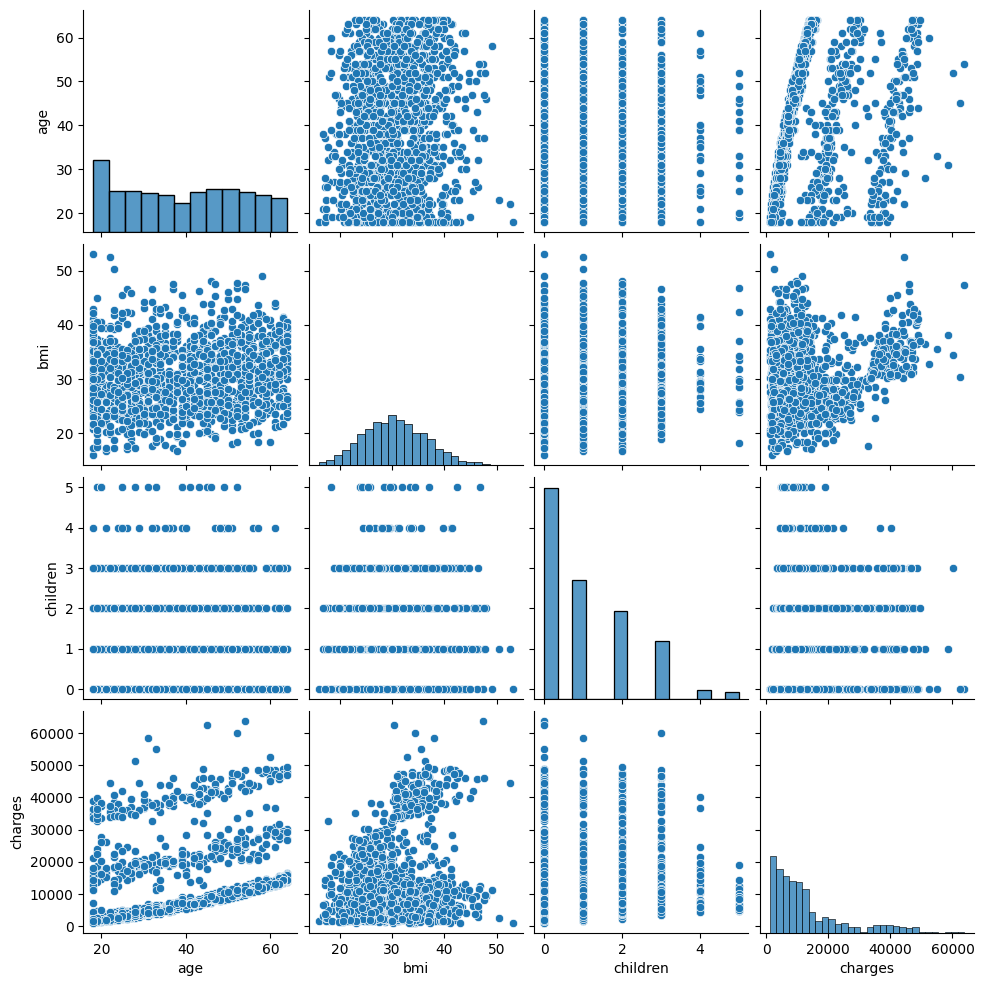

In [76]:
sns.pairplot(df)

<Axes: >

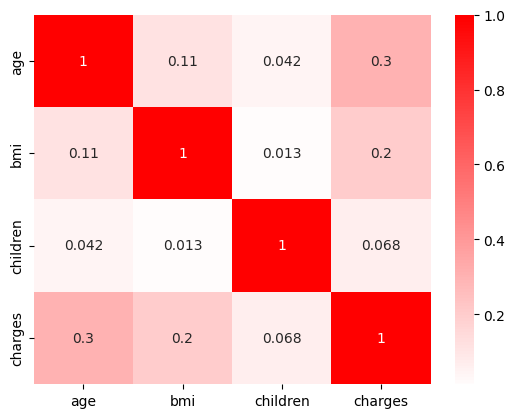

In [77]:
sns.heatmap(df[['age', 'bmi', 'children', 'charges']].corr(), cmap='bwr', center=0, annot=True)

Что в данных помешает нам сразу же построить хоть какую-нибудь модель?

Строковый тип данных. Модели в основном не умеют работать с текстом, есть те, что умеют обрабатывать категориальные данные, как в нашем случае, но для остальных моделей, как и для линейной регрессии, данные должны быть численными.

У нас есть три столбца для обработки: `sex`, `smoker`, `region`. Проще всего начать со столбца `smoker`. Что представляют собой данные? Как их можно записать в числах?

In [78]:
df['smoker'].unique()

array(['yes', 'no'], dtype=object)

По сути, это бинарный признак, принимающий два значения - "да" и "нет", которые также можно записать `True` и `False`, булево значение. А значит данные этого столбца можно смело заменить на нули и единицы.

In [79]:
df['smoker'] = df['smoker'].apply(lambda x: 0 if x=='no' else 1)

In [80]:
df['smoker'].unique()

array([1, 0])

Перейдём к столбцу `sex`, какие тут уникальные значения?

In [81]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

Всего два категориальных значения, но они не представимы сразу булевым типом. Что с ними можно сделать?

Да, их можно просто занумеровать нулями и единицами (главное запомнить, что есть что). Сделайте это.

In [82]:
df['sex'] = df['sex'].apply(lambda x: 0 if x=='female' else 1)

И вот мы добрались до третьего столбца, `region`, какие значения встречаются в нем?

In [83]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

Теперь поговорим о двух методах превращения категориальных столбцов в численные - прямое кодирование и порядковое кодирование.

Техника прямого кодирования, или отображения (англ. One-Hot Encoding, OHE). Принцип действия:
- Для каждого значения признака создаётся новый столбец.
- Если объекту категория подходит, присваивается 1, если нет — 0.

для прямого кодирования в библиотеке `pandas` есть функция `get_dummies()`.

In [84]:
pd.get_dummies(df['region']).head()

,northeast,northwest,southeast,southwest
0,False,False,False,True
1,False,False,True,False
2,False,False,True,False
3,False,True,False,False
4,False,True,False,False


Когда данных много, можно угодить в ловушку фиктивных признаков, это не очень хорошо для моделей. Также она называется дамми-ловушка (англ. dummy trap, «ловушка фиктивных признаков»).

Посмотрите на полученные сверху четыре столбца. Один из них можно смело удалять, ведь его легко восстановить из оставшихся, он избыточен. Для этого у функции `get_dummies()` есть аргумент `drop_first`. Если указать `True`, то первый из столбцов будет удалён.

In [85]:
pd.get_dummies(df['region'], drop_first=True).head()

,northwest,southeast,southwest
0,False,False,True
1,False,True,False
2,False,True,False
3,True,False,False
4,True,False,False


Обратите внимание, в целом это очень похоже на то, что мы сделали с двумя другими столбцами. Если их обработать техникой прямого кодирования и удалить один из столбцов, получится то же самое. Собственно, функция `get_dummies()` умеет сама определять категориальные переменные и обрабатывать их. Попробуйте передать в функцию весь датасет и посмотрите, как обработаются интересующие нас столбцы.

In [86]:
df = pd.read_csv('insurance.csv')

In [87]:
pd.get_dummies(df).head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


Второй подход - техника порядкового кодирования. Она подходит для порядковых категориальных признаков.

Есть функция. позволяющая закодировать цифрами выраженные в тексте категории —  Ordinal Encoding (от англ. «кодирование по номеру категории»). Она работает так:
- Фиксируется, какой цифрой кодируется класс.
- Цифры размещаются в столбце.

In [88]:
from sklearn.preprocessing import OrdinalEncoder

In [89]:
df = pd.read_csv('insurance.csv')

In [90]:
encoder = OrdinalEncoder()
data_ordinal = pd.DataFrame(encoder.fit_transform(df), columns=df.columns)

In [91]:
data_ordinal.head()

,age,sex,bmi,children,smoker,region,charges
0,1.0,0.0,197.0,0.0,1.0,3.0,1005.0
1,0.0,1.0,350.0,1.0,0.0,2.0,57.0
2,10.0,1.0,331.0,3.0,0.0,2.0,306.0
3,15.0,1.0,73.0,0.0,0.0,1.0,1097.0
4,14.0,1.0,223.0,0.0,0.0,1.0,254.0


Как выбрать одну из техникам кодирования категориальных переменных?
- Если все признаки должны стать количественными, подходит техника OHE.
- Когда все признаки категориальные, и их нужно преобразовать в числа — Ordinal Encoding.

Определитесь с наилучшей техникой для имеющихся данных и одготовьте набор данных для дальнейшей работы. Посмотрите также на парные распределения у получившихся столбцов и матрицу кореляций.

In [102]:
df = pd.read_csv('insurance.csv')

In [103]:
df = df.join(pd.get_dummies(df['region'], drop_first=True)).drop(['region'], axis=1)
df['sex'] = df['sex'].apply(lambda x: 0 if x=='female' else 1)
df['smoker'] = df['smoker'].apply(lambda x: 0 if x=='no' else 1)
df.head()

,age,sex,bmi,children,smoker,charges,northwest,southeast,southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


# Множественная линейная регрессия

Линейная регрессия может строиться и на нескольких признаках, тогда получается некая прямая в многомерном пространстве, которую далеко не всегда можно визуализировать.

Разделите подготовленные данные на `features` и `target` и постройте модель `LinearRegression`.

In [104]:
df = df.drop(['southeast'], axis=1)
features = df.drop(['charges'], axis=1)
target = df['charges']

In [105]:
reg = LinearRegression().fit(features, target)

In [106]:
reg.coef_

array([  257.79062599,  -128.79042768,   323.68124263,   476.25458063,
       23812.81029261,   158.75819844,  -426.91332526])

In [107]:
reg.intercept_

np.float64(-12029.668412332314)

Для того, чтобы увидеть больше разнообразных метрик, позволяющих оценить качество модели и подбирать набор признаков, используем аналогичную модель из другой библиотеки.

In [111]:
import statsmodels.api as sm
import numpy as np

В данном случае свободную переменную необходимо добавлять вручную, также можно не делать этого и строить регрессию без свободной переменной.

In [112]:
features = sm.add_constant(features)

In [114]:
features = features.astype(float)
model = sm.OLS(target, features)

In [115]:
results = model.fit()

In [116]:
results.params

,0
const,-12029.668412
age,257.790626
sex,-128.790428
bmi,323.681243
children,476.254581
smoker,23812.810293
northwest,158.758198
southwest,-426.913325


Сравните коэффициенты двух моделей.

Но самым главным плюсом использования данной библиотеки является метод `summaries()`, представляющий подробную сводку об оценке модели.

In [117]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     570.1
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:16:15   Log-Likelihood:                -13550.
No. Observations:                1338   AIC:                         2.712e+04
Df Residuals:                    1330   BIC:                         2.716e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.203e+04    988.282    -12.172      0.000    -1.4e+04   -1.01e+04
age          257.7906     11.907     21.650      0.000     234.431     281.150
sex         -128.7904    333.403     -0.386      0.699    -782.844     525.263
bmi          323.6812     27.723     11.675      0.000     269.295     378.067
children     476.2546    137.994      3.451      0.001     205.545     746.964
smoker      2.381e+04    413.393     57.603      0.000     2.3e+04    2.46e+04
northwest    158.7582    413.882      0.384      0.701    -653.175     970.691
southwest   -426.9133    409.981     -1.041      0.298   -1231.194     377.367
==============================================================================
Omnibus:                      298.716   Durbin-Watson:                   2.090
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              710.920
Skew:                           1.207   Prob(JB):                    4.22e-155
Kurtosis:                       5.631   Cond. No.                         309.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Вывод достаточно объёмный и состоит из трех частей.

- В первой представлены основные оценки модели, где присутсвует в том числе разобранный выше $R^2$.
- Во второй части дана информация по коэффициентам.
- Третья часть представляет анализ остатков.

Подробное описание можно прочитать [в статье](https://habr.com/ru/articles/681218/).

Нас сейчас интересует вторая часть, так как она позволяет производить отбор признаков.

В этой таблице присутствуют сами подобранные коэффициенты; дисперсия коэффициента `std err`; t-критерий Стьюдента; p-value, позволяющее принимать и отвергать гипотезы о значимости коэффициентов; доверительные интервалы коэффициентов.

Как раз по p-value можно смотреть, важен ли тот или иной признак для модели. Если p-value меньше 0.05 (или 0.01, два классических значения для оценки), то гипотеза о значимости принимается. В ином случае нулевая гипотеза отвергается, признак можно считать неважным. Значит, его можно удалять.

Важно! Если по таблице гипотеза отвергается сразу для нескольких признаков, не стоит удалять их все сразу - после удаления одного p-value для других могут значительно измениться. Поэтому убираем признаки по одному, начиная с самого большого p-value. Останавливаемся, когда p-value всех признаков будет укладываться в заданые рамки.

Попробуйте удалять признаки и заново строить регрессию. Станут ли лучше метрики?